# sim_study_rippler_2

## preamble

In [1]:
# importing numpy
import numpy as np
from numpy import random

In [2]:
# importing plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
%matplotlib inline

In [3]:
# importing storage for results
import zarr

In [4]:
# importing pandas
import pandas as pd

## simulated data

In [5]:
# loading in functions for simulation
%run '../../function_scripts_2/model/UC_simulation.py'

In [6]:
# importing the csv - only the important columns
data_real = pd.read_csv("../../Antidote_household.csv", usecols=["hid","pid","date","age","sex","hiv","hivChild","cpt","result","week"])

# converting the pid to integers (and saving lists of sex and age)
pid_unique = []
no_individuals = 0
test_individuals = []
sex = []
age = []
for i in range(1659):
    pid = data_real['pid'][i]
    if pid in pid_unique:
        test_individuals.append(pid_unique.index(pid))
    else:
        pid_unique.append(pid)
        test_individuals.append(no_individuals)
        sex.append(data_real['sex'][i])
        age.append(data_real['age'][i])
        no_individuals += 1
sex = np.array(sex)
age = np.array(age)

# centring age and sex
age = age - np.mean(age)
sex = sex - np.mean(sex)

# calculating N and T
N = no_individuals
T = int(max(data_real['week']))

# making a test result matrix (for the real test results)
test_results_real = np.tile(np.nan,(T+1,N))
for i in range(1659):
    j = test_individuals[i]
    t = int(data_real['week'][i])
    test_results_real[t,j] = data_real['result'][i]

# converting the hid to integers
hid_unique = []
no_houses = 0
test_houses = []
for hid in data_real['hid'] :
    if hid in hid_unique:
        test_houses.append(hid_unique.index(hid))
    else:
        hid_unique.append(hid)
        test_houses.append(no_houses)
        no_houses += 1

# list of which house each individual is in
house_list = []
for i in range(N):
    test_no = test_individuals.index(i)
    house_list.append(test_houses[test_no])

# making a household mixing matrix
h = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        if house_list[i]==house_list[j]:
            h[i,j] = 1

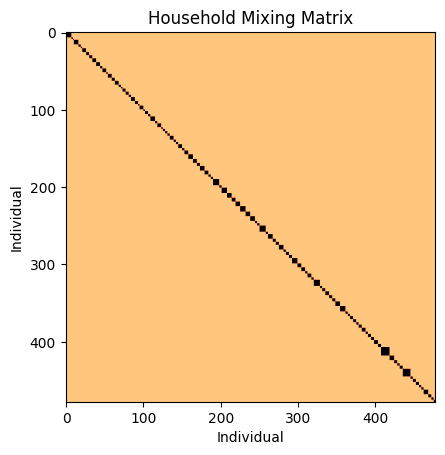

In [7]:
# plotting h
plt.imshow(h,cmap="copper_r")
plt.title("Household Mixing Matrix")
plt.ylabel("Individual")
plt.xlabel("Individual")
plt.show()

In [8]:
# true values of the paramters
theta = np.array([0.1,1.5,0,0])

In [9]:
# true values of other inputs
prop_0 = 0.3
gamma = 0.5
test_rate = 0.3 #will be replaced with other test data, but parameter needed for simulation
sens = 0.95
spec = 0.99

In [10]:
# seasonality modifiers
seasonality_mode = 2
seasonal_period = 52
t_ast = 17

# resulting matrices
seasonal_vector = np.array([1 - np.cos(2*np.pi*(t+t_ast)/seasonal_period) for t in range(T+1)])
seasonal_matrix_G = np.tile(seasonal_vector, (N,1)).T
seasonal_matrix_H = np.tile(1, (T+1,N))

In [11]:
# simulating the data
UC_results = UC_sim(N,h,age,sex,prop_0,theta,gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,1)

In [12]:
# creating a test result matrix
random.seed(256)
test_occurance = test_results_real*0 + 1
pos_prob = sens*UC_results['X'] + (1-spec)*(1-UC_results['X'])
test_outcome = random.binomial(1,pos_prob)
test_results = test_outcome * test_occurance

/tmp/ipykernel_3665087/1869204714.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
/tmp/ipykernel_3665087/1869204714.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")


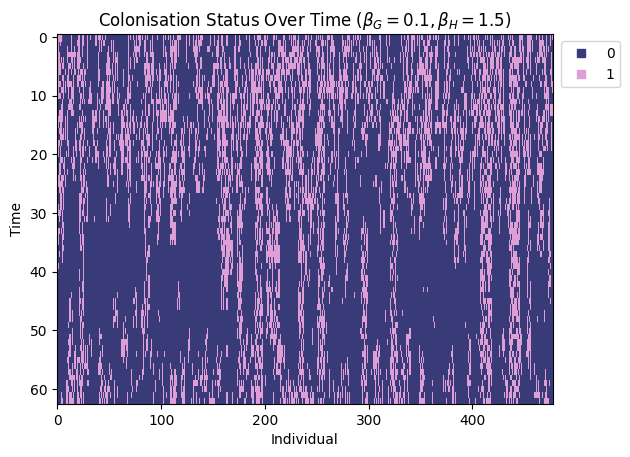

In [13]:
# plotting X
plt.imshow(UC_results['X'],cmap="tab20b",interpolation="nearest",aspect="auto")
#plt.colorbar()
colour0 = '#393b79'
plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
colour1 = '#de9ed6'
plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0), scatterpoints=1)
plt.title(r'Colonisation Status Over Time ($\beta_G=0.1, \beta_H=1.5$)')
plt.ylabel("Time")
plt.xlabel("Individual")
plt.show()

/tmp/ipykernel_3665087/127675635.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
/tmp/ipykernel_3665087/127675635.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")


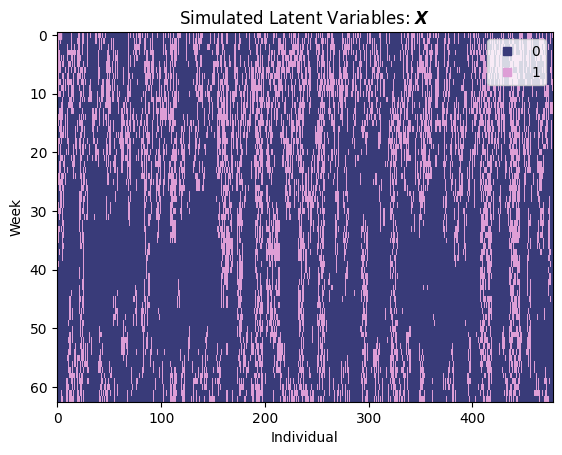

In [14]:
# plotting X
plt.imshow(UC_results['X'],cmap="tab20b",interpolation="nearest",aspect="auto")
#plt.colorbar()
colour0 = '#393b79'
plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
colour1 = '#de9ed6'
plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")
plt.legend(loc="upper right", scatterpoints=1)
plt.title(r'Simulated Latent Variables: $\boldsymbol{X}$')
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/latent_variables_for_poster.pdf")
plt.show()

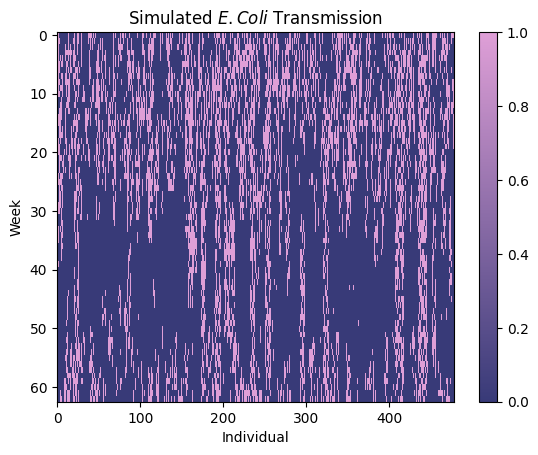

In [15]:
# plotting X
custom_map = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#383a78","#df9fd7"])
plt.imshow(UC_results['X'],cmap=custom_map,interpolation="nearest",aspect="auto")
plt.colorbar()
plt.title(r'Simulated $E. Coli$ Transmission')
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/latent_variables.pdf")
plt.show()

In [16]:
# simulating other datasets
UC_results2 = UC_sim(N,h,age,sex,prop_0,np.array([0.1,3,0,0]),gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,1)
UC_results3 = UC_sim(N,h,age,sex,prop_0,np.array([1.5,0.1,0,0]),gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,1)

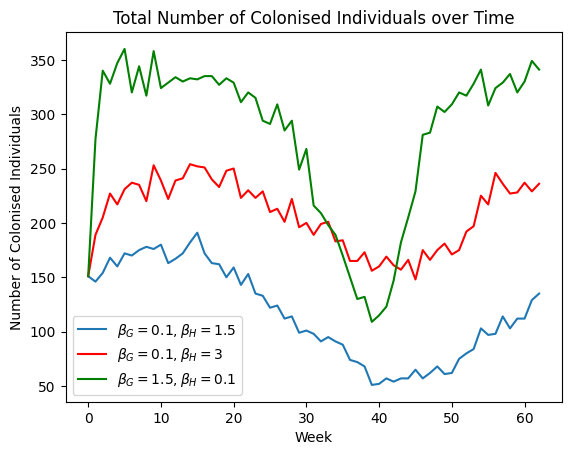

In [17]:
# plotting the number of colonised individuals over time
plt.plot(UC_results['sum_C'],label=r'$\beta_G=0.1, \beta_H=1.5$')
plt.plot(UC_results2['sum_C'],label=r'$\beta_G=0.1, \beta_H=3$',color="red")
plt.plot(UC_results3['sum_C'],label=r'$\beta_G=1.5, \beta_H=0.1$',color="green")
plt.legend()
plt.title("Total Number of Colonised Individuals over Time")
plt.ylabel("Number of Colonised Individuals")
plt.xlabel("Week")
plt.show()

/tmp/ipykernel_3665087/3765168887.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
/tmp/ipykernel_3665087/3765168887.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")


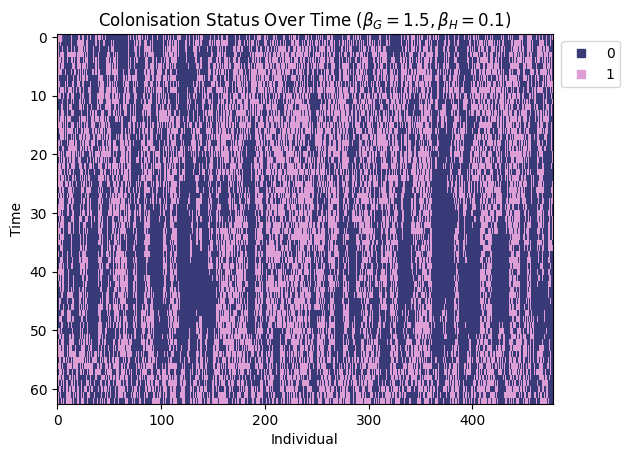

In [18]:
# plotting X
plt.imshow(UC_results2['X'],cmap="tab20b",interpolation="nearest",aspect="auto")
#plt.colorbar()
colour0 = '#393b79'
plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
colour1 = '#de9ed6'
plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0), scatterpoints=1)
plt.title(r'Colonisation Status Over Time ($\beta_G=1.5, \beta_H=0.1$)')
plt.ylabel("Time")
plt.xlabel("Individual")
plt.show()

/tmp/ipykernel_3665087/317312983.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="0", linestyle='', marker="s")
/tmp/ipykernel_3665087/317312983.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="1", linestyle='', marker="s")
/tmp/ipykernel_3665087/317312983.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour2, label="NA", linestyle='', marker="s")


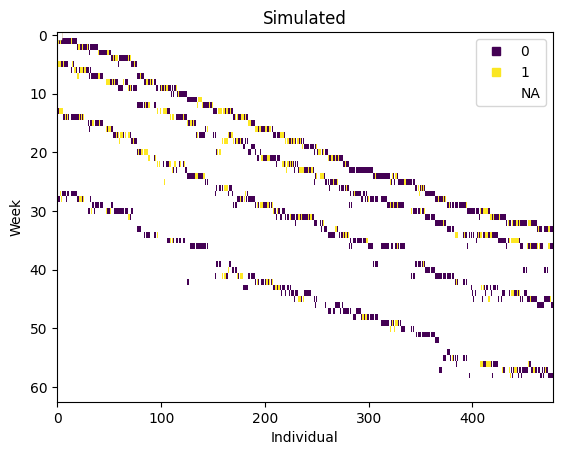

In [19]:
# looking at the test result matrix
plt.imshow(test_results,cmap="viridis",interpolation="nearest",aspect="auto")
colour0 = '#440154'
plt.plot(0, 0, "-", color=colour0, label="0", linestyle='', marker="s")
colour1 = '#fae622'
plt.plot(0, 0, "-", color=colour1, label="1", linestyle='', marker="s")
colour2 = '#ffffff'
plt.plot(0, 0, "-", color=colour2, label="NA", linestyle='', marker="s")
plt.legend(loc="upper right", scatterpoints=1)
plt.title(r'Simulated')
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/test_results_sim.pdf")
plt.show()

/tmp/ipykernel_3665087/4099121160.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="0", linestyle='', marker="s")
/tmp/ipykernel_3665087/4099121160.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="1", linestyle='', marker="s")
/tmp/ipykernel_3665087/4099121160.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour2, label="NA", linestyle='', marker="s")


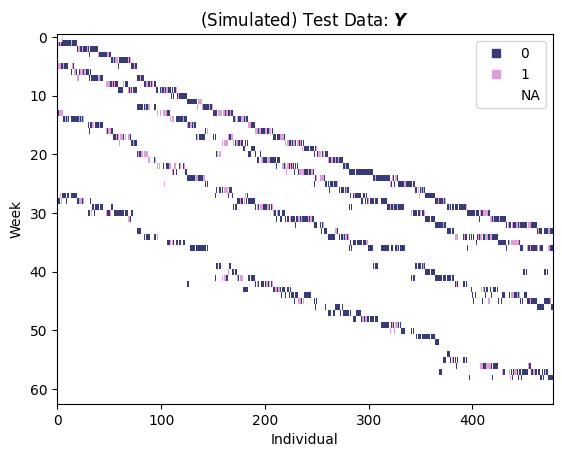

In [20]:
# looking at the test result matrix
plt.imshow(test_results,cmap="tab20b",interpolation="nearest",aspect="auto")
colour0 = '#393b79'
plt.plot(0, 0, "-", color=colour0, label="0", linestyle='', marker="s")
colour1 = '#de9ed6'
plt.plot(0, 0, "-", color=colour1, label="1", linestyle='', marker="s")
colour2 = '#ffffff'
plt.plot(0, 0, "-", color=colour2, label="NA", linestyle='', marker="s")
plt.legend(loc="upper right", scatterpoints=1)
plt.title(r'(Simulated) Test Data: $\boldsymbol{Y}$')
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/test_results_sim_for_poster.pdf")
plt.show()

In [21]:
# function to work out the number of TP/FP/TN/FNs
def test_acc(X:np.array,test_results:np.array) :
    
    # list of inputs:
    # X - matrix of all individuals colonisation status over time
    # test_results - matrix of all individuals colonisation status over time

    # creating a matrix comparing the results with the current latent variable values (0 for TPs or TNs, 1 for FPs, -1 for FNs, and nan for no tests)
    test_diff_matrix = test_results - X

    # calculating the number of TP/FP/TN/FNs from this matrix
    TP = np.sum((test_diff_matrix==0)*X)
    FN = np.sum(test_diff_matrix==-1)
    FP = np.sum(test_diff_matrix==1)
    TN = np.sum((test_diff_matrix==0)*(1-X))

    # returning outputs
    output = {'TP':TP, 'FN':FN, 'FP':FP, 'TN':TN}
    return output

In [22]:
# the number of TP/FP/TN/FNs
test_acc(UC_results['X'],test_results)

{'TP': 383, 'FN': 17, 'FP': 16, 'TN': 1157}

## inference information

In [23]:
# hyperparameters of priors
mu = np.array([0.001,0.001,0.001,0.001])
prior_X_0 = 0.3

In [24]:
# starting values
theta_start = np.array([0.2,4,0.02,0.5])
X_start = UC_sim(N,h,age,sex,prop_0,theta,gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,1)['X']
covariance_start = 0.8*0.000001*np.identity(4)
scaling = 0.8

In [25]:
# MCMC iterations
K = 100000
K_latent = 400

## acceptance rates

In [26]:
# importing the saved acceptance rates
MCMC_noncentred_acc = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/acc.zarr', mode='r')

# printing the acceptance rates
print("acc_theta:", MCMC_noncentred_acc[0])
print("acc_initial:", MCMC_noncentred_acc[1])
print("acc_latent:", MCMC_noncentred_acc[2])

# removing the acceptance rates from memory
del(MCMC_noncentred_acc)

acc_theta: 0.31203
acc_initial: 0.305706
acc_latent: 0.541433


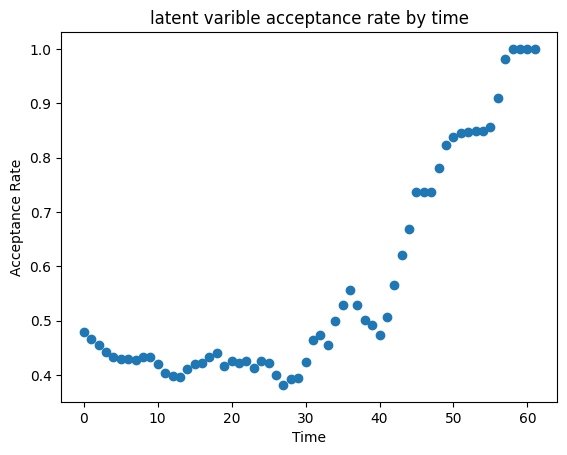

In [27]:
# importing the saved acceptance rates
MCMC_noncentred_acc_latent_times = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/acc_latent_times.zarr', mode='r')

# plotting the acceptance rate at each point in time
plt.scatter(range(T),MCMC_noncentred_acc_latent_times[:])
lobf = np.polyfit(range(T),MCMC_noncentred_acc_latent_times[:],1)
plt.title("latent varible acceptance rate by time")
plt.xlabel("Time")
plt.ylabel("Acceptance Rate")
plt.show()

# removing the acceptance rates from memory
del(MCMC_noncentred_acc_latent_times)

## parameters

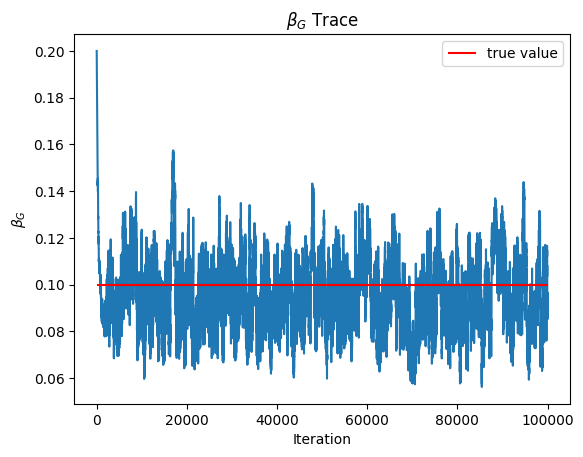

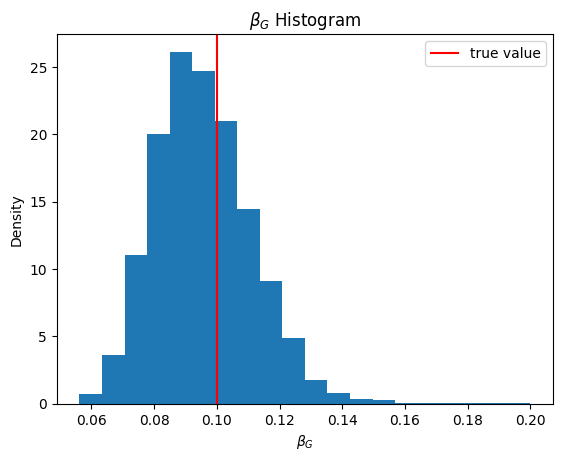

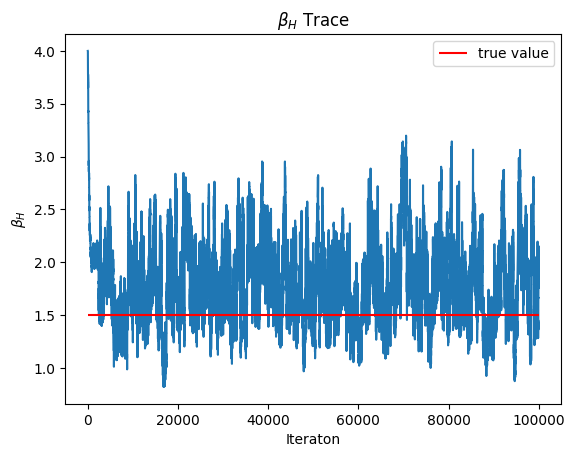

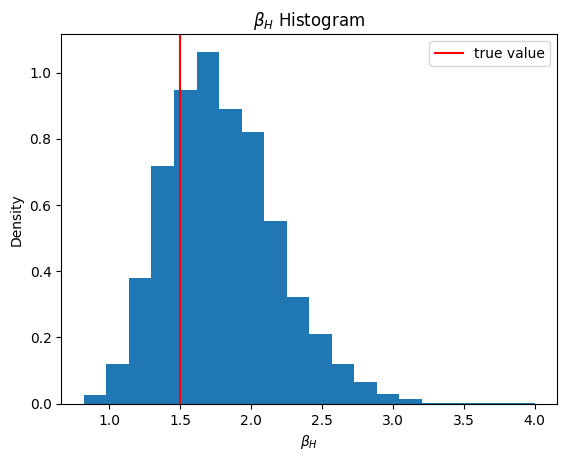

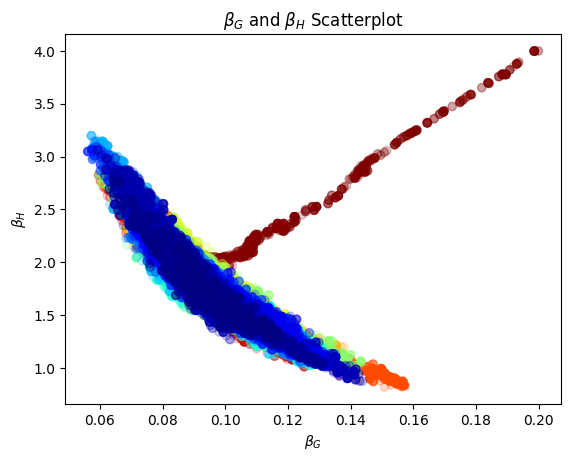

In [28]:
# importing the saved run of theta
MCMC_noncentred_theta = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/theta.zarr', mode='r')

# trace plot and histogram of beta_G
plt.plot(MCMC_noncentred_theta[:K,0])
plt.hlines(np.array(theta[0]),0,K,colors="red",label="true value")
plt.legend()
plt.title(r'$\beta_G$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$\beta_G$')
plt.show()
plt.hist(MCMC_noncentred_theta[:K,0],density=1,bins=20)
plt.axvline(theta[0],color="red",label="true value")
plt.legend()
plt.title(r'$\beta_G$ Histogram')
plt.xlabel(r'$\beta_G$')
plt.ylabel("Density")
plt.show()

# trace plot and histogram of beta_H
plt.plot(MCMC_noncentred_theta[:K,1])
plt.hlines(np.array(theta[1]),0,K,colors="red",label="true value")
plt.legend()
plt.title(r'$\beta_{H}$ Trace')
plt.xlabel("Iteraton")
plt.ylabel(r'$\beta_{H}$')
plt.show()
plt.hist(MCMC_noncentred_theta[:K,1],density=1,bins=20)
plt.axvline(theta[1],color="red",label="true value")
plt.legend()
plt.title(r'$\beta_{H}$ Histogram')
plt.xlabel(r'$\beta_{H}$')
plt.ylabel("Density")
plt.show()

# correlation plot of beta_G vs beta_H
plt.scatter(MCMC_noncentred_theta[:K,0],MCMC_noncentred_theta[:K,1],alpha=0.2,color=plt.cm.jet(np.linspace(1,0,K)))
plt.title(r'$\beta_G \text{ and } \beta_{H}$ Scatterplot')
plt.xlabel(r'$\beta_G$')
plt.ylabel(r'$\beta_{H}$')
plt.show()

# removing the traces of theta from memory
del(MCMC_noncentred_theta)

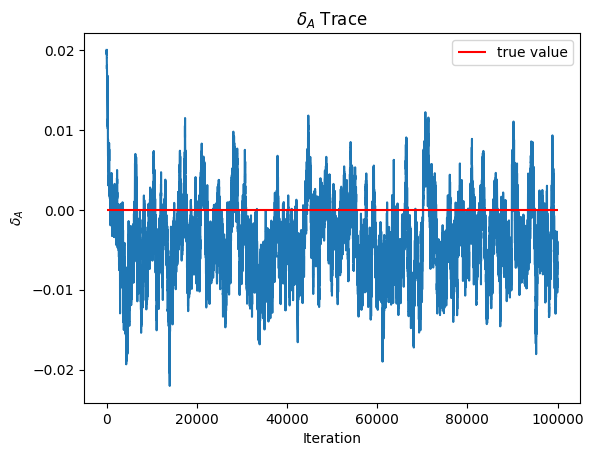

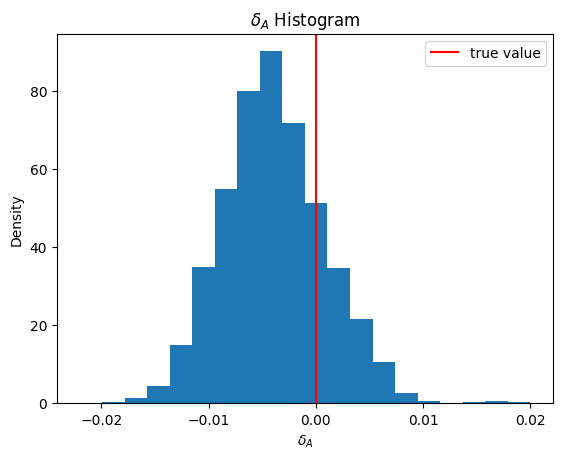

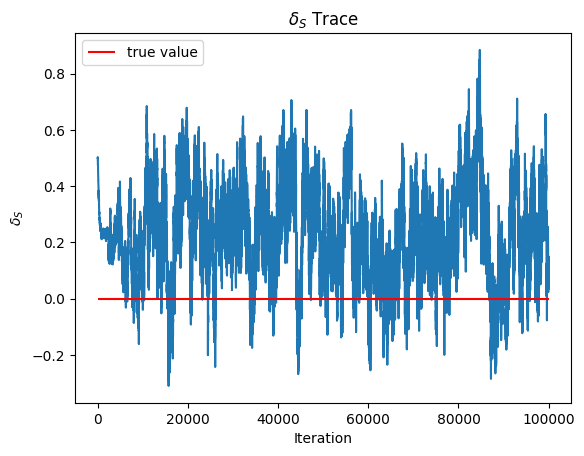

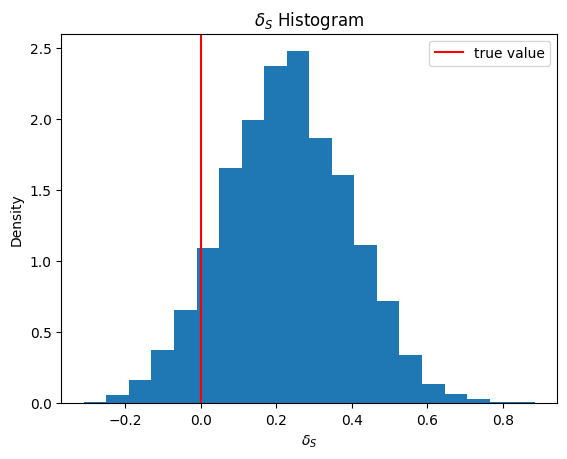

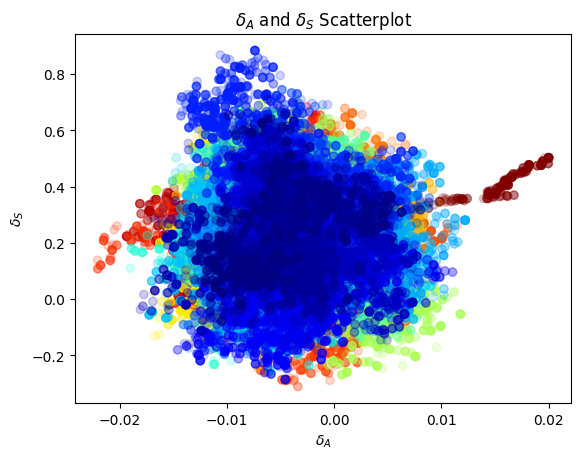

In [29]:
# importing the saved run of theta
MCMC_noncentred_theta = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/theta.zarr', mode='r')

# trace plot and histogram of delta_A
plt.plot(MCMC_noncentred_theta[:K,2])
plt.hlines(np.array(theta[2]),0,K,colors="red",label="true value")
plt.legend()
plt.title(r'$\delta_A$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$\delta_A$')
plt.show()
plt.hist(MCMC_noncentred_theta[:K,2],density=1,bins=20)
plt.axvline(theta[2],color="red",label="true value")
plt.legend()
plt.title(r'$\delta_A$ Histogram')
plt.xlabel(r'$\delta_A$')
plt.ylabel("Density")
plt.show()

# trace plot and histogram of delta_S
plt.plot(MCMC_noncentred_theta[:K,3])
plt.hlines(np.array(theta[3]),0,K,colors="red",label="true value")
plt.legend()
plt.title(r'$\delta_S$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$\delta_S$')
plt.show()
plt.hist(MCMC_noncentred_theta[:K,3],density=1,bins=20)
plt.axvline(theta[3],color="red",label="true value")
plt.legend()
plt.title(r'$\delta_S$ Histogram')
plt.xlabel(r'$\delta_S$')
plt.ylabel("Density")
plt.show()

# correlation plot of deltas
plt.scatter(MCMC_noncentred_theta[:K,2],MCMC_noncentred_theta[:K,3],alpha=0.2,color=plt.cm.jet(np.linspace(1,0,K)))
plt.title(r'$\delta_A \text{ and } \delta_S$ Scatterplot')
plt.xlabel(r'$\delta_A$')
plt.ylabel(r'$\delta_S$')
plt.show()

# removing the traces of theta from memory
del(MCMC_noncentred_theta)

## latent variables

In [36]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/X.zarr', mode='r')

# finding the quantiles
quantile_array = np.zeros((T+1,3))
for t in range(T+1):
    #print(t)
    quantile_array[t] = np.quantile(np.sum(MCMC_noncentred_X[10000:,t,:],axis=-1),[0.025,0.5,0.975])

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

In [37]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/X.zarr', mode='r')

# picking a random MCMC iteration
random.seed(123)
iterations = random.randint(10000,K,5)
print(iterations)
random_path_0 = np.sum(MCMC_noncentred_X[iterations[0],:,:],axis=-1)
random_path_1 = np.sum(MCMC_noncentred_X[iterations[1],:,:],axis=-1)
random_path_2 = np.sum(MCMC_noncentred_X[iterations[2],:,:],axis=-1)
random_path_3 = np.sum(MCMC_noncentred_X[iterations[3],:,:],axis=-1)
random_path_4 = np.sum(MCMC_noncentred_X[iterations[4],:,:],axis=-1)

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

[13582 21646 11346 22252 15218]


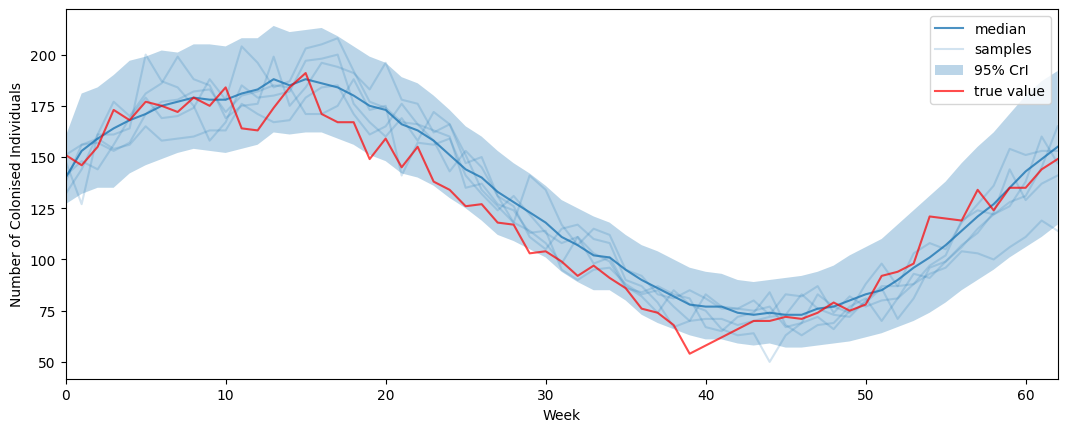

In [38]:
# 95% credible interval and median vs true (burn-in removed)
plt.figure(figsize=(12.8,4.8))
plt.plot(quantile_array[:,1], alpha=0.8, label="median")
plt.plot(random_path_0, alpha=0.2, color="tab:blue", label="samples")
plt.plot(random_path_1, alpha=0.2, color="tab:blue")
plt.plot(random_path_2, alpha=0.2, color="tab:blue")
plt.plot(random_path_3, alpha=0.2, color="tab:blue")
plt.plot(random_path_4, alpha=0.2, color="tab:blue")
plt.fill_between(range(T+1), quantile_array[:,0], quantile_array[:,2], alpha=0.3, label="95% CrI")
plt.plot(np.sum(UC_results['X'],axis=1), color="red", alpha=0.7, label="true value")
plt.legend(loc="upper right")
#plt.title("Number of Colonised Individuals")
plt.xlabel("Week")
plt.ylabel("Number of Colonised Individuals")
plt.xlim(0,62)
#plt.savefig("plots/colonised.pdf")
plt.show()

In [39]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/X.zarr', mode='r')

# finding the mean
X_mean = np.zeros((T+1,N))
X_sd = np.zeros((T+1,N))
for t in range(T+1):
    X_mean[t] = np.mean(MCMC_noncentred_X[10000:,t],axis=0)
    X_sd[t] = np.std(MCMC_noncentred_X[10000:,t],axis=0)
    #print(t)

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

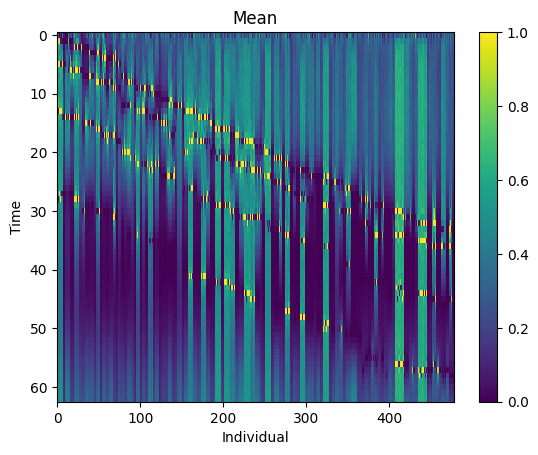

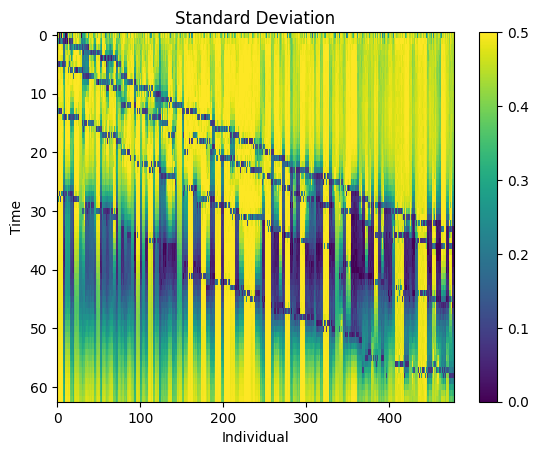

In [40]:
# plotting the mean and std
plt.imshow(X_mean,interpolation="nearest",aspect="auto",vmin=0,vmax=1)
plt.title(r'Mean')
plt.colorbar()
plt.ylabel("Time")
plt.xlabel("Individual")
plt.show()
plt.imshow(X_sd,interpolation="nearest",aspect="auto",vmin=0)
plt.title(r'Standard Deviation')
plt.colorbar()
plt.ylabel("Time")
plt.xlabel("Individual")
plt.show()

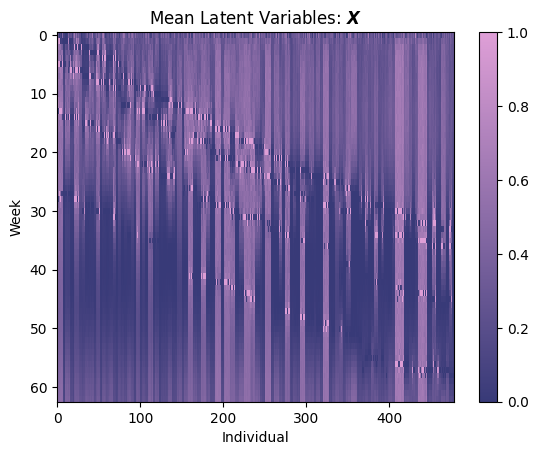

In [41]:
# plotting the mean
custom_map = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#383a78","#df9fd7"])
plt.imshow(X_mean,interpolation="nearest",cmap=custom_map,aspect="auto",vmin=0,vmax=1)
plt.title(r'Mean Latent Variables: $\boldsymbol{X}$')
plt.colorbar()
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/mean_latent_for_poster.pdf")
plt.show()

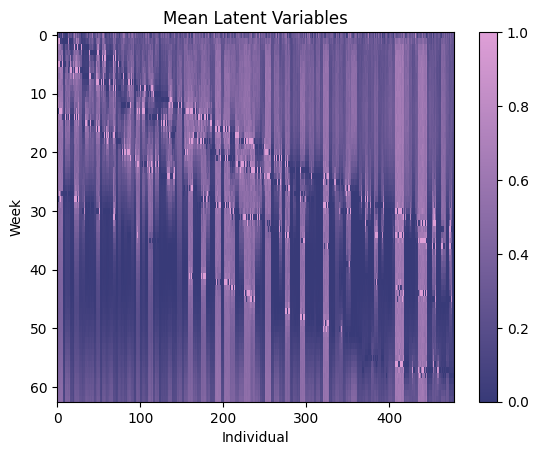

In [42]:
# plotting the mean
custom_map = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#383a78","#df9fd7"])
plt.imshow(X_mean,interpolation="nearest",cmap=custom_map,aspect="auto",vmin=0,vmax=1)
plt.title(r'Mean Latent Variables')
plt.colorbar()
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/mean_latent.pdf")
plt.show()

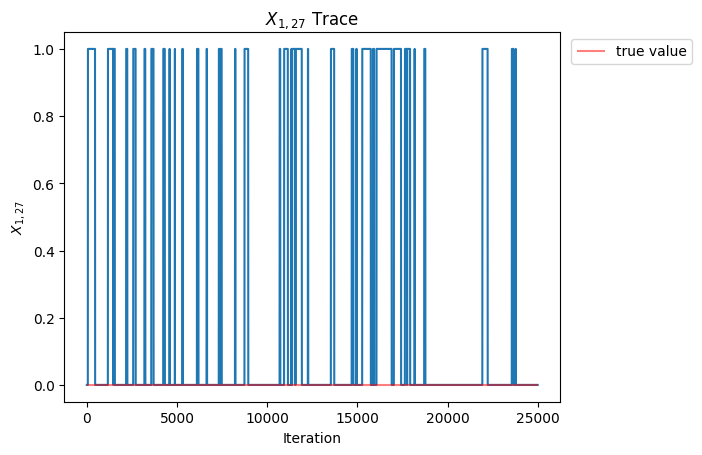

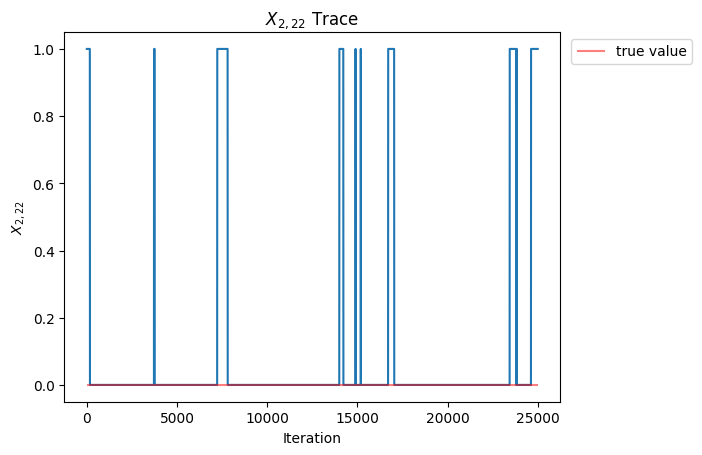

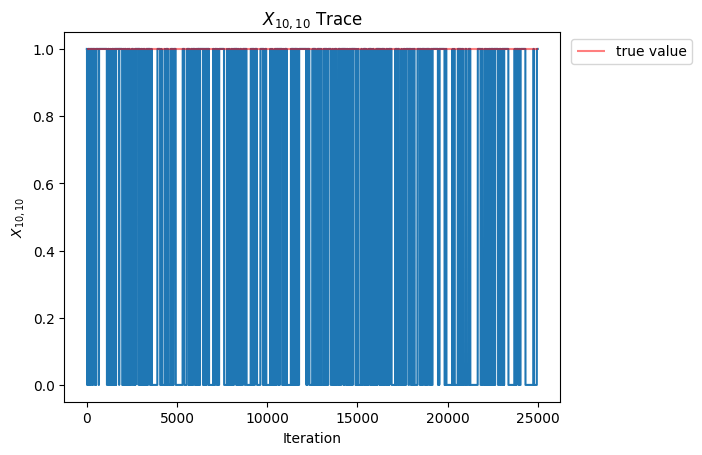

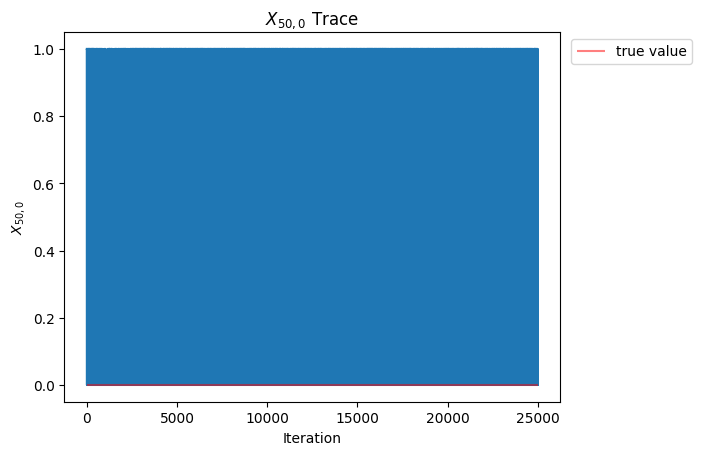

In [43]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/X.zarr', mode='r')

# Trace plots of elements of X
plt.plot(MCMC_noncentred_X[:,1,27])
plt.hlines(UC_results['X'][1,27],0,K,colors="red",alpha=0.5,label="true value")
plt.legend(loc="upper right", bbox_to_anchor=(1.28, 1.0))
plt.title(r'$X_{1,27}$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$X_{1,27}$')
plt.show()
plt.plot(MCMC_noncentred_X[:,2,22])
plt.hlines(UC_results['X'][2,22],0,K,colors="red",alpha=0.5,label="true value")
plt.legend(loc="upper right", bbox_to_anchor=(1.28, 1.0))
plt.title(r'$X_{2,22}$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$X_{2,22}$')
plt.show()
plt.plot(MCMC_noncentred_X[:,10,10])
plt.hlines(UC_results['X'][10,10],0,K,colors="red",alpha=0.5,label="true value")
plt.legend(loc="upper right", bbox_to_anchor=(1.28, 1.0))
plt.title(r'$X_{10,10}$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$X_{10,10}$')
plt.show()
plt.plot(MCMC_noncentred_X[:,50,0])
plt.hlines(UC_results['X'][50,0],0,K,colors="red",alpha=0.5,label="true value")
plt.legend(loc="upper right", bbox_to_anchor=(1.28, 1.0))
plt.title(r'$X_{50,0}$ Trace')
plt.xlabel("Iteration")
plt.ylabel(r'$X_{50,0}$')
plt.show()

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

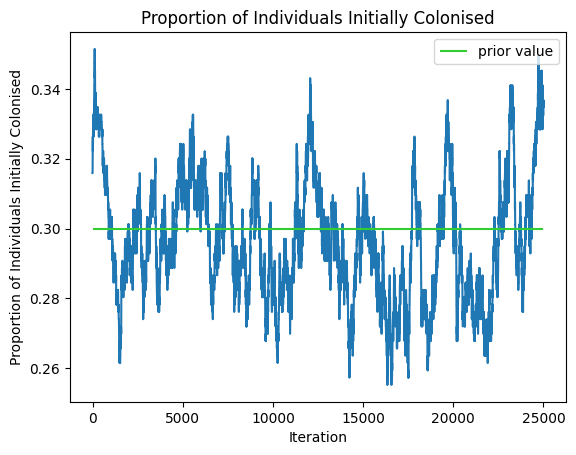

In [44]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_2/MCMC_output_3/X.zarr', mode='r')

# proportion of individuals colonised at time 0
plt.plot(np.average(MCMC_noncentred_X[:,0,:],axis=1))
#plt.hlines(np.average(UC_results['X'][0]),0,K,colors="red",label="true value")
plt.hlines(prior_X_0,0,K,colors="limegreen",label="prior value")
plt.legend(loc = "upper right")
plt.title("Proportion of Individuals Initially Colonised")
plt.xlabel("Iteration")
plt.ylabel("Proportion of Individuals Initially Colonised")
plt.show()

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

## end